In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [2]:
df = pd.read_csv("data_std_filter.csv")

In [3]:
# predictor variables (same as BM axis variables)
predictors = [
    "prop_car_0",
    "prop_ethnic_white",
    "prop_class_never_worked",
    "prop_dep_4"
]

# dependent variable (same as BM colouring variable)
X = sm.add_constant(df[predictors])
y = df["ahah_pct"]

model = sm.OLS(y, X).fit()

In [4]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               ahah_pct   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     2873.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:36:14   Log-Likelihood:            -1.4761e+05
No. Observations:               32067   AIC:                         2.952e+05
Df Residuals:                   32062   BIC:                         2.953e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [5]:
#Mediation test
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("data_std_filter.csv")

def run_ols(y, X_vars, label):
    X = sm.add_constant(df[X_vars])
    model = sm.OLS(df[y], X).fit()
    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")
    print(f"R² = {model.rsquared:.4f} | F = {model.fvalue:.2f} | N = {int(model.nobs)}")
    print(f"\n{'Variable':<30} {'Coef':>8} {'p>|t|':>8} {'Sig':>5}")
    print("-"*55)
    for var in model.params.index:
        p   = model.pvalues[var]
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
        print(f"{var:<30} {model.params[var]:>8.3f} {p:>8.4f} {sig:>5}")
    return model

# Total effect: ethnicity on AHAH
m1 = run_ols("ahah_pct", ["prop_ethnic_white"],
             "Total effect: prop_ethnic_white -> ahah_pct")

# Ethnicity on mediator (car deprivation)
m2 = run_ols("prop_car_0", ["prop_ethnic_white"],
             "Ethnicity -> car deprivation (mediator)")

# Mediator on outcome controlling for ethnicity
m3 = run_ols("ahah_pct", ["prop_ethnic_white", "prop_car_0"],
             "Both ethnicity + car deprivation -> ahah_pct")

# Summary
print(f"Ethnicity -> AHAH (total effect):        β = {m1.params['prop_ethnic_white']:.3f}")
print(f"Ethnicity -> Car deprivation:            β = {m2.params['prop_ethnic_white']:.3f}")
print(f"Ethnicity -> AHAH (direct, controlling")
print(f"         for car deprivation):                   β = {m3.params['prop_ethnic_white']:.3f}")
print(f"Car deprivation -> AHAH (controlling")
print(f"         for ethnicity):                         β = {m3.params['prop_car_0']:.3f}")

b1 = m1.params['prop_ethnic_white']
b3 = m3.params['prop_ethnic_white']
indirect = b1 - b3
pct_mediated = (indirect / b1) * 100

print(f"\nTotal effect:                           β = {b1:.3f}")
print(f"Direct effect:                          β = {b3:.3f}")
print(f"Indirect effect (mediation via car deprivation): β = {indirect:.3f}")
print(f"% of total effect mediated by car deprivation:    {pct_mediated:.1f}%")

if abs(b3) < abs(b1) and abs(b3) > 0.01:
    print("\n→ PARTIAL MEDIATION: car deprivation partially mediates")
    print("  the ethnicity-AHAH relationship")
elif abs(b3) < 0.01:
    print("\n→ FULL MEDIATION: car deprivation fully mediates")
    print("  the ethnicity-AHAH relationship")
else:
    print("\n→ NO MEDIATION detected")

# Sobel test for significance of indirect effect
import numpy as np
a     = m2.params['prop_ethnic_white']
b     = m3.params['prop_car_0']
se_a  = m2.bse['prop_ethnic_white']
se_b  = m3.bse['prop_car_0']

sobel_se = np.sqrt(b**2 * se_a**2 + a**2 * se_b**2)
sobel_z  = (a * b) / sobel_se
sobel_p  = 2 * (1 - __import__('scipy').stats.norm.cdf(abs(sobel_z)))

print(f"\nSobel test of indirect effect:")
print(f"  Indirect effect (a×b): {a*b:.4f}")
print(f"  Sobel z-statistic:     {sobel_z:.4f}")
print(f"  p-value:               {sobel_p:.4f}")
print(f"  Significant:           {'Yes ***' if sobel_p < 0.001 else 'Yes **' if sobel_p < 0.01 else 'Yes *' if sobel_p < 0.05 else 'No'}")


Total effect: prop_ethnic_white -> ahah_pct
R² = 0.2005 | F = 8039.84 | N = 32067

Variable                           Coef    p>|t|   Sig
-------------------------------------------------------
const                           106.482   0.0000   ***
prop_ethnic_white                -0.644   0.0000   ***

Ethnicity -> car deprivation (mediator)
R² = 0.2559 | F = 11025.40 | N = 32067

Variable                           Coef    p>|t|   Sig
-------------------------------------------------------
const                            53.163   0.0000   ***
prop_ethnic_white                -0.376   0.0000   ***

Both ethnicity + car deprivation -> ahah_pct
R² = 0.2543 | F = 5466.87 | N = 32067

Variable                           Coef    p>|t|   Sig
-------------------------------------------------------
const                            78.851   0.0000   ***
prop_ethnic_white                -0.448   0.0000   ***
prop_car_0                        0.520   0.0000   ***
Ethnicity -> AHAH (total effect)

In [6]:
# =========================
# ROBUST STANDARD ERRORS
# =========================

model_robust = sm.OLS(y, X).fit(cov_type='HC3')
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:               ahah_pct   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     4949.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:36:22   Log-Likelihood:            -1.4761e+05
No. Observations:               32067   AIC:                         2.952e+05
Df Residuals:                   32062   BIC:                         2.953e+05
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [7]:
# =========================
# MULTICOLLINEARITY CHECK (VIF)
# =========================

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)

                  variable        VIF
0                    const  74.099904
1               prop_car_0   2.101837
2        prop_ethnic_white   1.491768
3  prop_class_never_worked   2.147599
4               prop_dep_4   1.543627


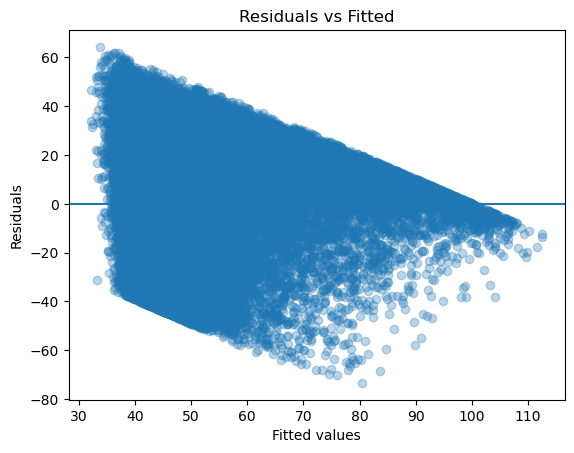

In [8]:
# =========================
# RESIDUAL CHECK
# =========================

import matplotlib.pyplot as plt

plt.scatter(model.fittedvalues, model.resid, alpha=0.3)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [9]:
# =========================
# FUNCTIONAL FORM ROBUSTNESS (LOGIT TRANSFORMATION)
# =========================

import numpy as np

# Step 1: convert to proportion
df["ahah_prop"] = df["ahah_pct"] / 100

# Step 2: avoid 0 and 1
df["ahah_prop"] = df["ahah_prop"].clip(0.001, 0.999)

# Step 3: logit transform
df["ahah_logit"] = np.log(df["ahah_prop"] / (1 - df["ahah_prop"]))

# Step 4: run OLS on transformed outcome
X = sm.add_constant(df[predictors])
y_logit = df["ahah_logit"]

model_logit = sm.OLS(y_logit, X).fit(cov_type='HC3')

print(model_logit.summary())

                            OLS Regression Results                            
Dep. Variable:             ahah_logit   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     3331.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:36:29   Log-Likelihood:                -57087.
No. Observations:               32067   AIC:                         1.142e+05
Df Residuals:                   32062   BIC:                         1.142e+05
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

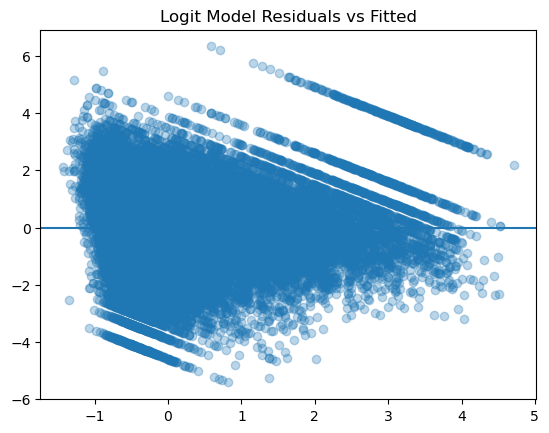

In [10]:
plt.scatter(model_logit.fittedvalues, model_logit.resid, alpha=0.3)
plt.axhline(0)
plt.title("Logit Model Residuals vs Fitted")
plt.show()

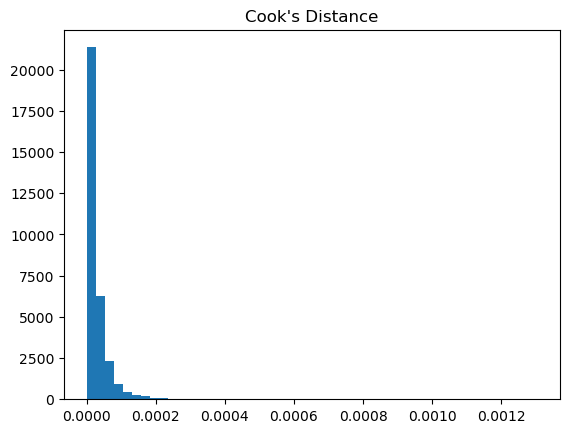

In [11]:
# =========================
# INFLUENCE CHECK
# =========================

influence = model.get_influence()
cooks = influence.cooks_distance[0]

plt.hist(cooks, bins=50)
plt.title("Cook's Distance")
plt.show()

In [12]:
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

threshold = 4 / len(df)

print("Cook's D threshold:", threshold)
print("Max Cook's D:", cooks_d.max())

Cook's D threshold: 0.0001247388280787102
Max Cook's D: 0.0013048541507816468


In [13]:
# =========================
# SPECIFICATION CHECK (DROP VARIABLES)
# =========================

for var in predictors:
    reduced = [v for v in predictors if v != var]
    X_reduced = sm.add_constant(df[reduced])
    m = sm.OLS(y, X_reduced).fit()
    print(f"\nModel without {var}")
    print(m.params)


Model without prop_car_0
const                      97.917075
prop_ethnic_white          -0.594938
prop_class_never_worked     1.009801
prop_dep_4                  5.180424
dtype: float64

Model without prop_ethnic_white
const                      34.736577
prop_car_0                  0.856383
prop_class_never_worked     0.132261
prop_dep_4                 -2.947860
dtype: float64

Model without prop_class_never_worked
const                79.711663
prop_car_0            0.577196
prop_ethnic_white    -0.454237
prop_dep_4           -5.000592
dtype: float64

Model without prop_dep_4
const                      94.853185
prop_car_0                  0.657162
prop_ethnic_white          -0.500405
prop_class_never_worked    -5.220354
dtype: float64


In [14]:
# =========================
# REPLACEMENT VARIABLE TEST
# =========================

predictors_alt = [
    "prop_car_0",
    "prop_ethnic_white",
    "prop_class_never_worked",
    "prop_dep_2"
]

X_alt = sm.add_constant(df[predictors_alt])
model_alt = sm.OLS(y, X_alt).fit()

print(model_alt.summary())

                            OLS Regression Results                            
Dep. Variable:               ahah_pct   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     2943.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:36:43   Log-Likelihood:            -1.4751e+05
No. Observations:               32067   AIC:                         2.950e+05
Df Residuals:                   32062   BIC:                         2.951e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [15]:
# =========================
# MEDIATION BOOTSTRAP
# =========================

boot_effects = []

for _ in range(200):
    sample = df.sample(frac=1, replace=True)

    m2 = sm.OLS(sample["prop_car_0"],
                sm.add_constant(sample["prop_ethnic_white"])).fit()

    m3 = sm.OLS(sample["ahah_pct"],
                sm.add_constant(sample[["prop_ethnic_white", "prop_car_0"]])).fit()

    indirect = m2.params["prop_ethnic_white"] * m3.params["prop_car_0"]
    boot_effects.append(indirect)

print("Mean indirect effect:", np.mean(boot_effects))
print("95% CI:", np.percentile(boot_effects, [2.5, 97.5]))

Mean indirect effect: -0.19583024001437024
95% CI: [-0.20278612 -0.1877696 ]
